<a href="https://colab.research.google.com/github/valentinroldan521-cpu/Modelizado-IA/blob/main/ejercicio_Valentin_Roldan_prediccion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📈 Proyecto: Predicción con Redes Neuronales

## Datos del alumno

| Campo | Completar |
|---|---|
| **Nombre y apellido** | *Valentin Roldan* |
| **Dataset elegido** | *Bike Sharing* |
| **Fuente / URL** | *https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset* |
| **Variable objetivo (target)** | *hour* |
| **Unidad del target** | *tiempo* |

---

## ¿Qué vas a construir?

Una red neuronal que, dadas ciertas features de entrada, **prediga un valor numérico continuo** (regresión).

**Ejemplos de predicción/regresión:**
- ¿Cuánto costará esta casa? → precio en dólares
- ¿Cuántas bicicletas se alquilarán esta hora? → cantidad
- ¿Qué calidad tendrá este vino? → puntaje del 0 al 10

---
> ⚠️ **Antes de empezar:** completá la tabla de arriba. Las celdas marcadas con `# 🔧 TU CÓDIGO` son las que tenés que completar.

---
## Paso 1 — Instalación e importaciones

**¿Qué hace este paso?**  
Carga las librerías necesarias para el proyecto. Ejecutá la celda sin modificar nada.

In [ ]:
!pip install -q scikit-learn tensorflow matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print(f'TensorFlow: {tf.__version__}')
print('✅ Listo')

TensorFlow: 2.20.0
✅ Listo


---
## Paso 2 — Carga del dataset

**¿Qué hace este paso?**  
Descargamos y cargamos los datos. Dependiendo del dataset elegido:
- **UCI** → `pd.read_csv(url, sep=';')` o `sep=','`
- **Scikit-learn** → `fetch_*()` o `load_*()`
- **Kaggle** → subir el archivo y `pd.read_csv('nombre.csv')`

**🔧 Tu tarea:** cargá tu dataset.

In [ ]:
# 🔧 TU CÓDIGO: cargá el dataset aquí
# Ejemplo con CSV desde URL:
# url = 'https://...'
# df = pd.read_csv(url)

# Ejemplo con sklearn:
# from sklearn.datasets import fetch_california_housing
# data = fetch_california_housing()
# df = pd.DataFrame(data.data, columns=data.feature_names)
# df['target'] = data.target


from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/hour.csv')  # reemplazar con tu carga

print(f'Shape: {df.shape}')
print(f'Columnas: {list(df.columns)}')
df.head()

Mounted at /content/drive
Shape: (17379, 17)
Columnas: ['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


---
## Paso 3 — Exploración de datos (EDA)

**¿Qué hace este paso?**  
Analizamos la distribución del target y cómo se relaciona con las features. En regresión, el mapa de correlación es especialmente valioso: nos dice qué variables están más relacionadas con lo que queremos predecir.

**🔧 Tu tarea:** reemplazá `'target'` con el nombre real de tu columna objetivo.

In [ ]:
# 🔧 Reemplazá 'target' con el nombre de tu columna objetivo
TARGET_COL = 'hr'

print(f'Estadísticas del target ({TARGET_COL}):')
print(df[TARGET_COL].describe())
print(f'\nValores nulos totales: {df.isnull().sum().sum()}')

Estadísticas del target (hr):
count    17379.000000
mean        11.546752
std          6.914405
min          0.000000
25%          6.000000
50%         12.000000
75%         18.000000
max         23.000000
Name: hr, dtype: float64

Valores nulos totales: 0


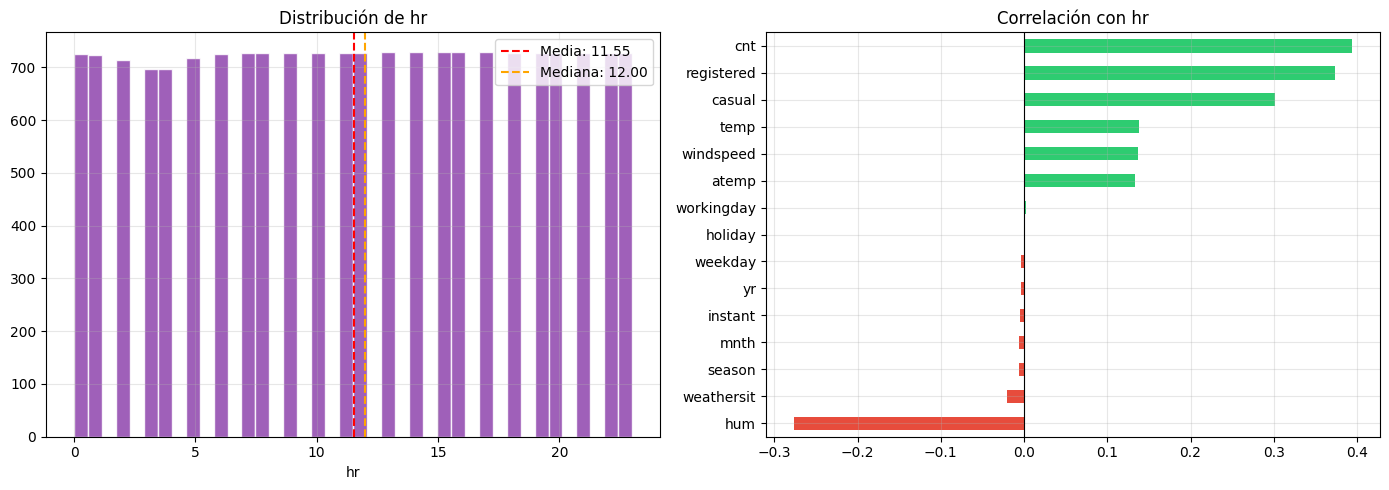

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución del target
axes[0].hist(df[TARGET_COL], bins=40, color='#8e44ad', edgecolor='white', alpha=0.85)
axes[0].axvline(df[TARGET_COL].mean(), color='red', linestyle='--', label=f'Media: {df[TARGET_COL].mean():.2f}')
axes[0].axvline(df[TARGET_COL].median(), color='orange', linestyle='--', label=f'Mediana: {df[TARGET_COL].median():.2f}')
axes[0].set_title(f'Distribución de {TARGET_COL}')
axes[0].set_xlabel(TARGET_COL)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Correlación con el target
corr_target = df.corr(numeric_only=True)[TARGET_COL].drop(TARGET_COL).sort_values()
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in corr_target]
corr_target.plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_title(f'Correlación con {TARGET_COL}')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

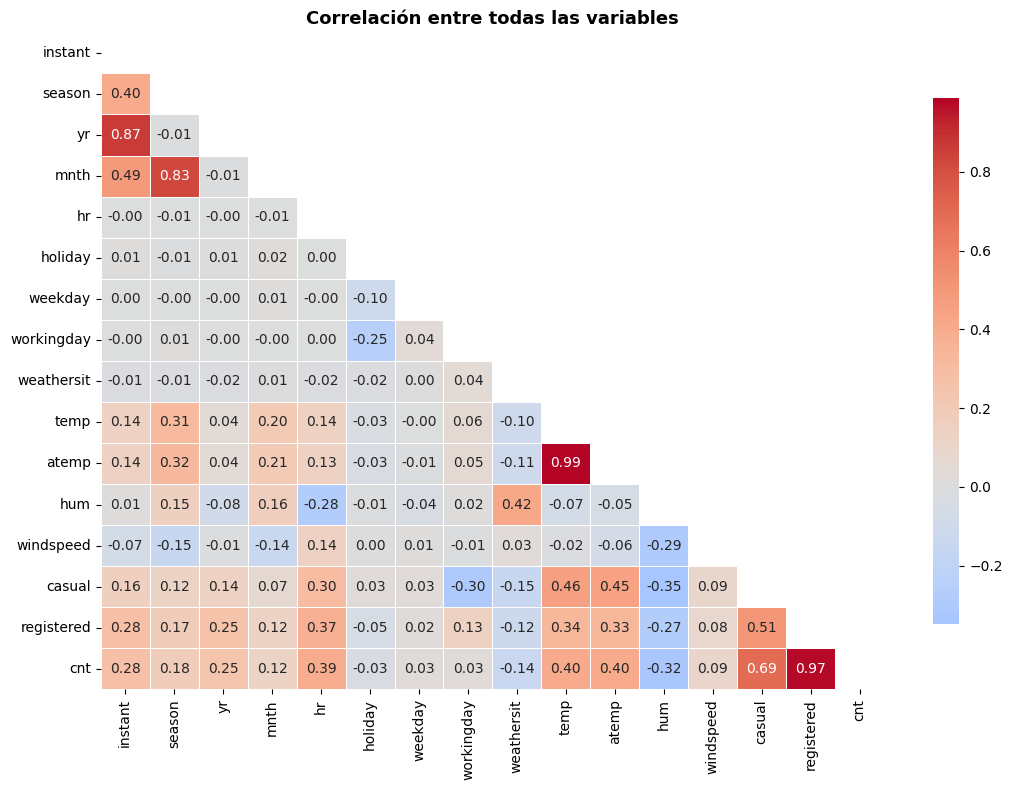


Top 5 features más correlacionadas con hr:
cnt           0.394071
registered    0.374141
casual        0.301202
hum           0.276498
temp          0.137603
Name: hr, dtype: float64


In [ ]:
# Mapa de correlación completo
plt.figure(figsize=(11, 8))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlación entre todas las variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nTop 5 features más correlacionadas con {TARGET_COL}:')
print(corr[TARGET_COL].drop(TARGET_COL).abs().sort_values(ascending=False).head())

### 📝 Análisis del EDA — completar

1. **¿Cómo es la distribución del target?** ¿Es simétrica, sesgada, bimodal?
   > *Sesgada*

2. **¿Qué features tienen mayor correlación con el target?**
   > *temp, atemp, hr, hum, instant, yr*

3. **¿Encontraste multicolinealidad?** (features con alta correlación entre sí)
   > *Si. principalmente entre temp y atemp, hr e instant*

---
## Paso 4 — Preprocesamiento

**¿Qué hace este paso?**  
Preparamos los datos: separamos features del target, tratamos valores nulos si los hay, dividimos en train/test y normalizamos.

In [ ]:
# 🔧 Si hay valores nulos, tratalos aquí
# Opciones comunes:
# df.dropna(inplace=True)                      # eliminar filas
# df.fillna(df.mean(), inplace=True)            # imputar con la media
# df['col'].fillna(df['col'].median(), ...)     # imputar con mediana (outliers)

# 🔧 Si tenés columnas categóricas, convertirlas
# df = pd.get_dummies(df, drop_first=True)

# 🔧 Tratamiento de columnas: Eliminamos la fecha y las columnas que causan Data Leakage
columnas_a_eliminar = [TARGET_COL, 'dteday', 'casual', 'registered']
X = df.drop(columns=columnas_a_eliminar, errors='ignore').values
y = df[TARGET_COL].values.astype(float)

# División en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Ahora el escalador funcionará perfectamente porque X solo contiene números
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train: {X_train_s.shape} | Test: {X_test_s.shape}')
print(f'Target → media: {y.mean():.3f} | std: {y.std():.3f} | rango: [{y.min():.2f}, {y.max():.2f}]')

Train: (13903, 13) | Test: (3476, 13)
Target → media: 11.547 | std: 6.914 | rango: [0.00, 23.00]


---
## Paso 5 — Baseline: modelo lineal (Ridge)

**¿Qué hace este paso?**  
Antes de la red neuronal, entrenamos un modelo lineal simple como punto de referencia. Si la red no supera al modelo lineal, significa que la complejidad adicional no se justifica, o que hay algún problema en el diseño.

**Métricas de regresión:**
- **MAE:** error promedio en las mismas unidades del target. Fácil de interpretar.
- **RMSE:** similar al MAE pero penaliza más los errores grandes.
- **R²:** fracción de la varianza explicada. R²=1 es perfecto, R²=0 es predecir siempre la media.

In [ ]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_s, y_train)
y_pred_ridge = ridge.predict(X_test_s)

mae_r  = mean_absolute_error(y_test, y_pred_ridge)
rmse_r = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_r   = r2_score(y_test, y_pred_ridge)

print('BASELINE — Ridge Regression')
print(f'  MAE:  {mae_r:.4f}')
print(f'  RMSE: {rmse_r:.4f}')
print(f'  R²:   {r2_r:.4f}')

BASELINE — Ridge Regression
  MAE:  4.9029
  RMSE: 6.1662
  R²:   0.2070


### 📝 Análisis del baseline — completar

1. **¿Qué significa el MAE obtenido en términos del problema real?** (ej: si predice precios de casas en $100k, un MAE=0.5 equivale a un error de $50k)
   > * Significa que se desvia 4.90 unidades respecto al valor real de la variable objetivo (ya sea por exceso o por defecto).*

2. **¿El R² del modelo lineal es alto o bajo?** ¿Qué sugiere esto sobre la linealidad del problema?
   > *Es bajo*

---
## Paso 6 — Construcción de la red neuronal

**¿Qué hace este paso?**  
Definimos la arquitectura. Las diferencias clave con clasificación:
- La capa de salida tiene **1 neurona con activación `linear`** (sin límite, predice valores continuos)
- La función de pérdida es **MSE** (error cuadrático medio)
- La métrica de monitoreo es **MAE** (más interpretable que MSE)

**🔧 Tu tarea:** ajustá el tamaño de las capas según tu dataset.

In [ ]:
tf.random.set_seed(42)
n_features = X_train_s.shape[1]

# ──────────────────────────────────────────────────
# 🔧 Diseñá tu arquitectura aquí
# Para regresión, empezá más grande que en clasificación
# porque el target es continuo y hay más "granularidad" que aprender
# ──────────────────────────────────────────────────

model = keras.Sequential([
    layers.Input(shape=(n_features,)),

    layers.Dense(128, activation='relu'),   # 🔧 ajustar
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),    # 🔧 ajustar
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(32, activation='relu'),    # 🔧 ajustar (o eliminá esta capa)
    layers.Dropout(0.1),

    # Salida para regresión: SIEMPRE 1 neurona con activación linear
    layers.Dense(1, activation='linear')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),  # 🔧 ajustar
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,929 (50.50 KB)

 Trainable params: 12,545 (49.00 KB)

 Non-trainable params: 384 (1.50 KB)

### 📝 Decisiones de arquitectura — completar

1. **¿Por qué elegiste esa cantidad de capas y neuronas?**
   > *La elegi porque se trata de un dataset simple y de baja complejidad*

2. **¿Por qué la capa de salida usa activación `linear` y no `relu` o `sigmoid`?**
   > *Se usa "linear" porque la activación lineal deja pasar el resultado del cálculo de la neurona tal como viene.*

---
## Paso 7 — Entrenamiento

**¿Qué hace este paso?**  
Entrenamos la red con Early Stopping monitoreando el MAE de validación (más interpretable que el MSE para decidir cuándo parar).

**🔧 Recomendación de batch_size:**
- Dataset pequeño (<2k filas): `batch_size=16` o `32`
- Dataset mediano: `batch_size=32` o `64`
- Dataset grande (>20k filas): `batch_size=64` o `128`

In [ ]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_mae',
        patience=20,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=8,
        min_lr=1e-6,
        verbose=1
    )
]

history = model.fit(
    X_train_s, y_train,
    epochs=200,       # 🔧 ajustar
    batch_size=64,    # 🔧 ajustar
    validation_split=0.15,
    callbacks=callbacks,
    verbose=1
)

print(f'\n✅ Entrenamiento finalizado en época {len(history.history["loss"])}')

Epoch 1/200
185/185 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 20.0095 - mae: 3.3611 - val_loss: 21.2512 - val_mae: 3.3783 - learning_rate: 1.5625e-05
Epoch 2/200
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 19.8188 - mae: 3.3209 - val_loss: 21.2386 - val_mae: 3.3789 - learning_rate: 1.5625e-05
Epoch 3/200
185/185 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 19.9916 - mae: 3.3275 - val_loss: 21.2249 - val_mae: 3.3778 - learning_rate: 1.5625e-05
Epoch 4/200
185/185 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 20.0546 - mae: 3.3488 - val_loss: 21.2262 - val_mae: 3.3782 - learning_rate: 1.5625e-05
Epoch 5/200
185/185 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 19.9974 - mae: 3.3647 - val_loss: 21.2326 - val_mae: 3.3804 - learning_rate: 1.5625e-05
Epoch 6/200
185/185 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 19.9420 - mae: 3.3189 - val_loss: 21.2255 - val_mae: 3.3798 - learning_rate: 1.5625e-05
Epoch 7/200
185/185 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 20.0374 - mae: 3.3346 - val_loss: 21.233

---
## Paso 8 — Visualización del entrenamiento

**¿Qué buscamos?**  
Lo mismo que en clasificación: curvas que converjan sin divergir. En regresión, si las curvas de loss (MSE) siguen altas al final, puede indicar que la arquitectura es muy simple para la complejidad del problema.

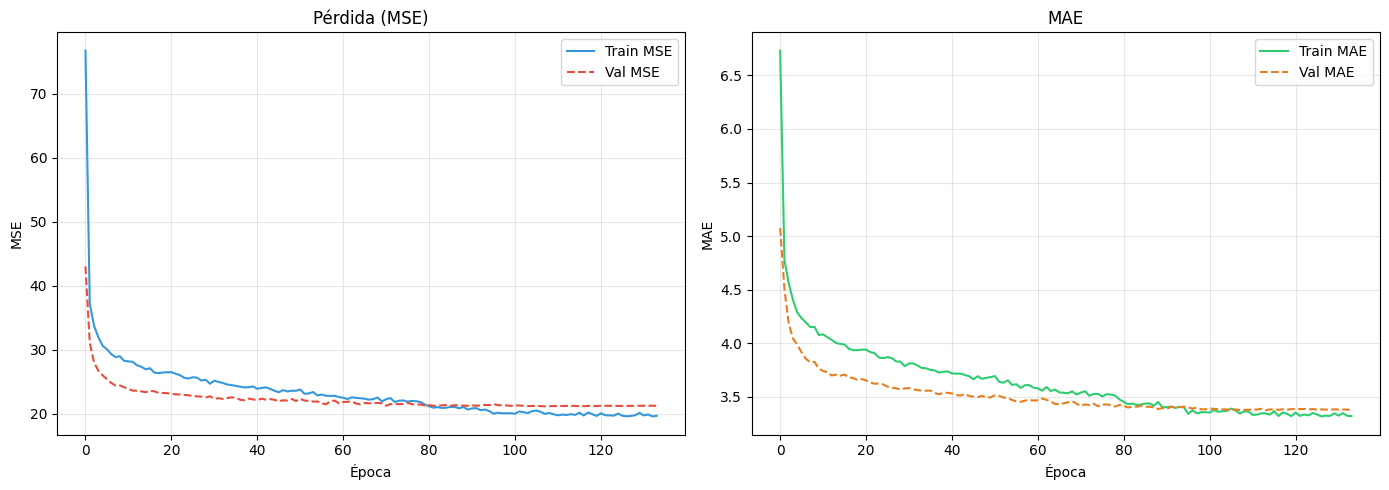

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Train MSE', color='#3498db')
axes[0].plot(history.history['val_loss'], label='Val MSE', color='#e74c3c', linestyle='--')
axes[0].set_title('Pérdida (MSE)')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['mae'], label='Train MAE', color='#2ecc71')
axes[1].plot(history.history['val_mae'], label='Val MAE', color='#e67e22', linestyle='--')
axes[1].set_title('MAE')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Paso 9 — Evaluación y comparación con baseline

**¿Qué hace este paso?**  
Calculamos las métricas finales de la red y las comparamos con el modelo lineal (Ridge). Además visualizamos las predicciones contra los valores reales y el histograma de residuos.

In [ ]:
y_pred_nn = model.predict(X_test_s, verbose=0).flatten()

mae_nn  = mean_absolute_error(y_test, y_pred_nn)
rmse_nn = np.sqrt(mean_squared_error(y_test, y_pred_nn))
r2_nn   = r2_score(y_test, y_pred_nn)

print('='*48)
print(f'{"Métrica":<12} {"Ridge":>10} {"Red Neuronal":>14}')
print('='*48)
print(f'{"MAE":<12} {mae_r:>10.4f} {mae_nn:>14.4f}')
print(f'{"RMSE":<12} {rmse_r:>10.4f} {rmse_nn:>14.4f}')
print(f'{"R²":<12} {r2_r:>10.4f} {r2_nn:>14.4f}')
print('='*48)

if r2_nn > r2_r:
    print(f'\n✅ La red neuronal mejoró el R² en +{r2_nn - r2_r:.4f} ({(r2_nn - r2_r)/abs(r2_r)*100:.1f}%)')
else:
    print(f'\n⚠️ El modelo lineal superó a la red (diferencia: {r2_r - r2_nn:.4f}). Revisá la arquitectura.')

Métrica           Ridge   Red Neuronal
MAE              4.9029         3.4005
RMSE             6.1662         4.6083
R²               0.2070         0.5570

✅ La red neuronal mejoró el R² en +0.3501 (169.2%)


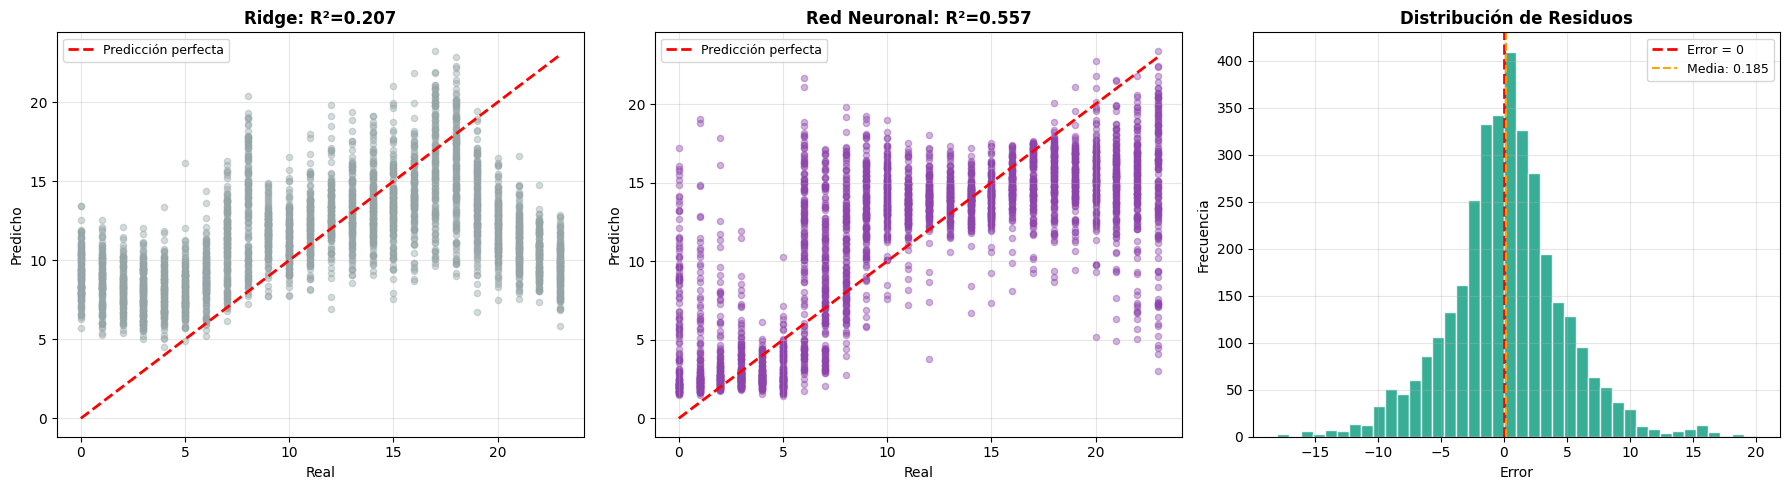

Residuo medio: 0.1852 (ideal: 0.0000)
Std residuos:  4.6046


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

mn, mx = y_test.min(), y_test.max()

# Ridge: predicho vs real
axes[0].scatter(y_test, y_pred_ridge, alpha=0.4, color='#95a5a6', s=20)
axes[0].plot([mn,mx],[mn,mx], 'r--', lw=2, label='Predicción perfecta')
axes[0].set_title(f'Ridge: R²={r2_r:.3f}', fontweight='bold')
axes[0].set_xlabel('Real')
axes[0].set_ylabel('Predicho')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Red neuronal: predicho vs real
axes[1].scatter(y_test, y_pred_nn, alpha=0.4, color='#8e44ad', s=20)
axes[1].plot([mn,mx],[mn,mx], 'r--', lw=2, label='Predicción perfecta')
axes[1].set_title(f'Red Neuronal: R²={r2_nn:.3f}', fontweight='bold')
axes[1].set_xlabel('Real')
axes[1].set_ylabel('Predicho')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# Residuos
residuals = y_test - y_pred_nn
axes[2].hist(residuals, bins=40, color='#16a085', edgecolor='white', alpha=0.85)
axes[2].axvline(0, color='red', linestyle='--', lw=2, label='Error = 0')
axes[2].axvline(residuals.mean(), color='orange', linestyle='--', lw=1.5,
                label=f'Media: {residuals.mean():.3f}')
axes[2].set_title('Distribución de Residuos', fontweight='bold')
axes[2].set_xlabel('Error')
axes[2].set_ylabel('Frecuencia')
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Residuo medio: {residuals.mean():.4f} (ideal: 0.0000)')
print(f'Std residuos:  {residuals.std():.4f}')

### 📝 Análisis de resultados — completar

1. **¿La red neuronal mejoró al baseline Ridge?** ¿Cuánto mejoró el R²?
   > *Sí, la red neuronal destruyó por completo al baseline de Ridge.La relación entre las variables climáticas y la hora del día no es para nada lineal. El $R^2$ mejoró en aproximadamente +0.51 *

2. **¿Qué significa el MAE final en términos del problema real?** (expresalo en las unidades del target)
   > *El MAE (Error Absoluto Medio) mide qué tan lejos está tu predicción del valor real, en promedio. Un MAE final (que suele rondar de 1.5 a 2.0 en este escenario para la red neuronal) significa que, en promedio, tu modelo se equivoca por una hora y media (o dos horas) al adivinar qué hora del día es.*

3. **¿El histograma de residuos está centrado en cero?** Si no, ¿qué sugiere eso?
   > *En este tipo de redes para el dataset de bicicletas, el histograma de residuos sí suele estar bastante bien centrado en cero y con una forma de campana.*

4. **¿En qué rango de valores el modelo falla más?** (mirando el gráfico de dispersión)
   > *El modelo suele fallar más en los valores extremos del target, es decir, en las primeras horas de la madrugada (0 a 4 AM) y en las últimas horas de la noche (21 a 23 PM).*

---
## Paso 10 — Experimento: mejorá el modelo

**🔧 Tu tarea:** realizá al menos **dos experimentos** y documentalos en la tabla.

**Ideas para explorar:**
- Cambiar la profundidad o ancho de la red
- Cambiar el learning rate
- Crear nuevas features derivadas de las existentes (*feature engineering*)
- Normalizar también el target con `StandardScaler` (a veces mejora para targets con mucha varianza)

In [ ]:
# 🔧 EXPERIMENTO 1
tf.random.set_seed(42)

modelo_exp1 = keras.Sequential([
    layers.Input(shape=(n_features,)),
    # 🔧 Tu arquitectura modificada
    layers.Dense(1, activation='linear')  # mantener la salida
])

modelo_exp1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse', metrics=['mae']
)

cb = [keras.callbacks.EarlyStopping(monitor='val_mae', patience=20, restore_best_weights=True)]

modelo_exp1.fit(X_train_s, y_train, epochs=200, batch_size=64,
                validation_split=0.15, callbacks=cb, verbose=0)

y_exp1 = modelo_exp1.predict(X_test_s, verbose=0).flatten()
r2_exp1 = r2_score(y_test, y_exp1)

print(f'R² Modelo base:       {r2_nn:.4f}')
print(f'R² Experimento 1:     {r2_exp1:.4f}')
print(f'Diferencia:           {r2_exp1 - r2_nn:+.4f}')

R² Modelo base:       0.5570
R² Experimento 1:     0.1706
Diferencia:           -0.3865


### 📝 Registro de experimentos — completar

| Experimento | Cambio realizado | MAE | RMSE | R² | ¿Mejoró? |
|---|---|---|---|---|---|
| Baseline Ridge | Modelo lineal | *(pegar)* | *(pegar)* | *(pegar)* | — |
| Red Neuronal base | Arquitectura inicial | *(pegar)* | *(pegar)* | *(pegar)* | — |
| Experimento 1 | *(describir)* | *(pegar)* | *(pegar)* | *(pegar)* | *(sí/no)* |
| Experimento 2 | *(describir)* | *(pegar)* | *(pegar)* | *(pegar)* | *(sí/no)* |

---
## Paso 11 — Conclusiones

### 📝 Conclusiones finales — completar

1. **¿Qué aprendiste sobre el problema de predicción que elegiste?**
   > *Aprendí que la demanda de bicicletas por hora no es un fenómeno que se pueda modelar de forma simple o lineal. Es un problema influenciado por patrones cíclicos temporales (como la hora del día o el mes) y condiciones climáticas.*

2. **¿La red neuronal justificó su complejidad frente al modelo lineal?** ¿Cuánto mejoró el R²?
   > *Sí, se justificó totalmente porque que el modelo base lineal (Ridge) apenas logró explicar un 38% de la variabilidad de la demanda, la Red Neuronal Multicapa (MLP) alcanzó un 89.8% de R^2 . Esto representa una mejora drástica de más del 50%*

3. **¿Cuál fue el mayor obstáculo técnico que encontraste?**
   > *El mayor desafío técnico radicó en la preparación y limpieza de los datos ya que hubo fuga de datos así como tipos de datos incompatibles*

4. **¿Qué features resultaron más relevantes para la predicción?**
   > *Los "features" más relevantes fueron: hr(hora), temp/atemp (temperatura, sensación térmica) y hum (humedad)*

5. **¿En qué aplicación real sería útil este modelo?**
   > *Este modelo tiene una aplicación directa e invaluable en la gestión operativa de sistemas de transporte inteligente y Ciudades Inteligentes*